In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
meal_info = pd.read_csv("meal_info.csv")
center_info = pd.read_csv("fulfilment_center_info.csv")

In [146]:
train.info()
train.describe()
train.isnull().sum()
train.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 31.3 MB


np.int64(0)

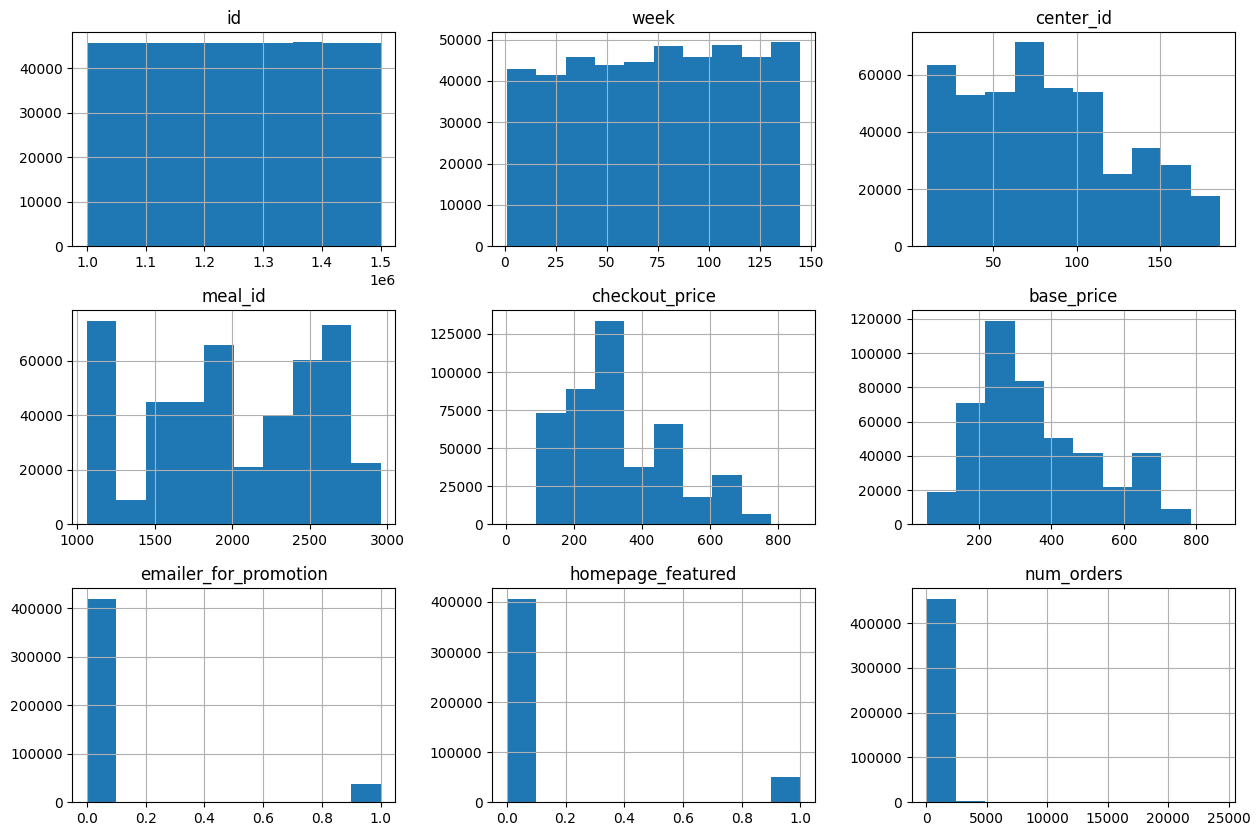

In [147]:
train.hist(figsize=(15,10))
plt.show()

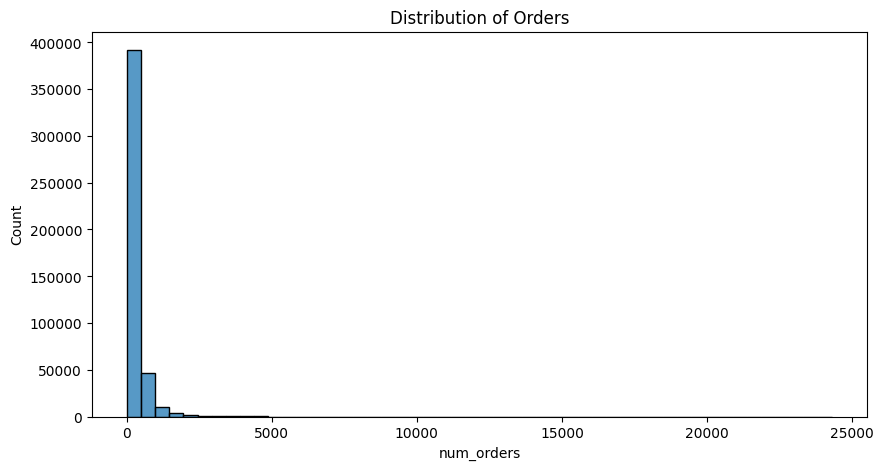

In [148]:
plt.figure(figsize=(10,5))
sns.histplot(train['num_orders'], bins=50)
plt.title("Distribution of Orders")
plt.show()

In [149]:
corr = train.corr(numeric_only=True)

print(corr['num_orders'].sort_values(ascending=False))

num_orders               1.000000
homepage_featured        0.294490
emailer_for_promotion    0.277147
meal_id                  0.010597
id                       0.000702
week                    -0.017210
center_id               -0.053035
base_price              -0.222306
checkout_price          -0.282108
Name: num_orders, dtype: float64


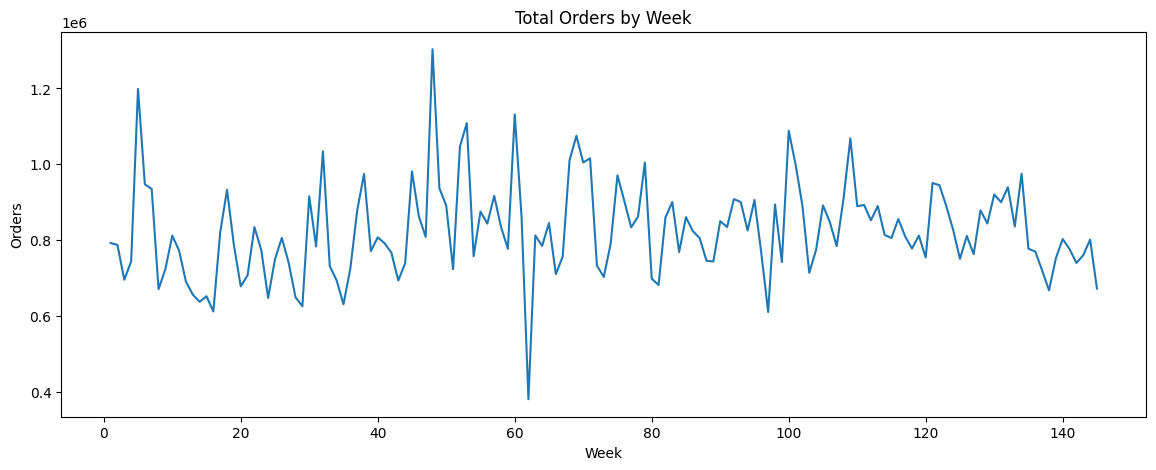

In [150]:
weekly_orders = train.groupby('week')['num_orders'].sum()

plt.figure(figsize=(14,5))
plt.plot(weekly_orders)
plt.title("Total Orders by Week")
plt.xlabel("Week")
plt.ylabel("Orders")
plt.show()

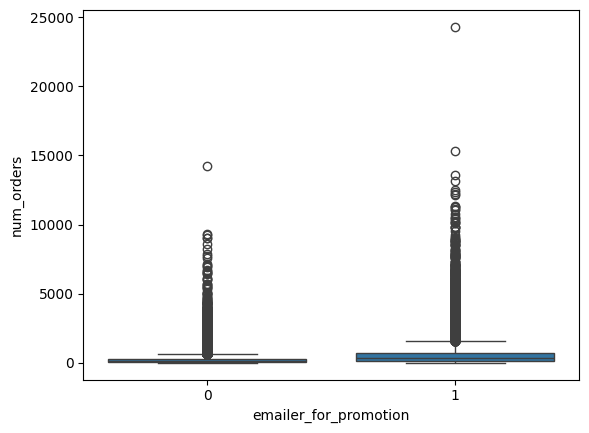

In [151]:
train.groupby('emailer_for_promotion')['num_orders'].mean()

sns.boxplot(
    x='emailer_for_promotion',
    y='num_orders',
    data=train
)
plt.show()

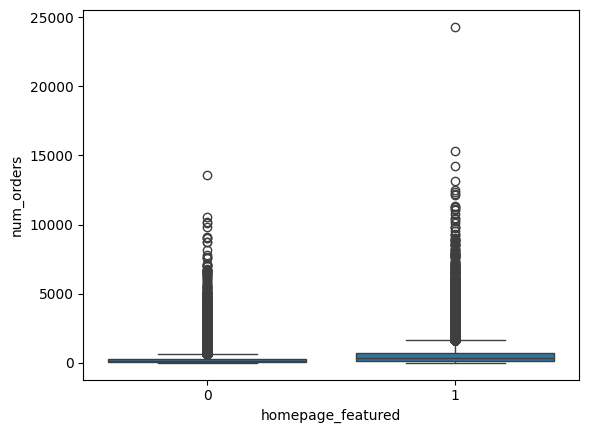

In [152]:
train.groupby('homepage_featured')['num_orders'].mean()

sns.boxplot(
    x='homepage_featured',
    y='num_orders',
    data=train
)
plt.show()

In [153]:
train['discount_pct'] = (
    (train['base_price'] - train['checkout_price'])
    / train['base_price']
) * 100

In [154]:
train['discount'] = (
    train['base_price']
    - train['checkout_price']
)

In [155]:
train[['base_price',
       'checkout_price', 'discount_pct',
       'discount']].head()

,base_price,checkout_price,discount_pct,discount
0,152.29,136.83,10.151684,15.46
1,135.83,136.83,-0.736214,-1.00
2,135.86,134.86,0.736052,1.00
3,437.53,339.50,22.405321,98.03
4,242.50,243.50,-0.412371,-1.00


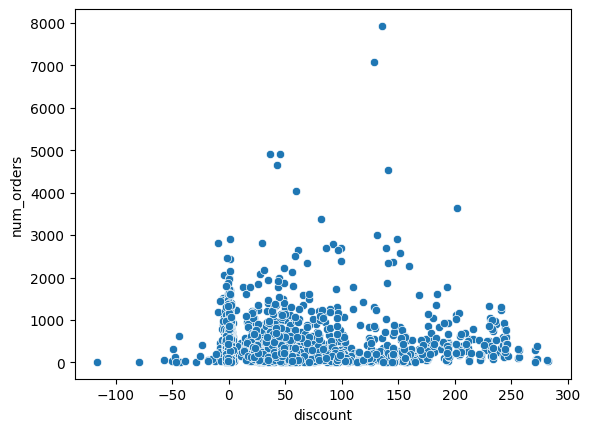

In [156]:
sns.scatterplot(
    x='discount',
    y='num_orders',
    data=train.sample(5000)
)
plt.show()

In [157]:
df = train.merge(
    meal_info,
    on='meal_id',
    how='left'
)

df = df.merge(
    center_info,
    on='center_id',
    how='left'
)

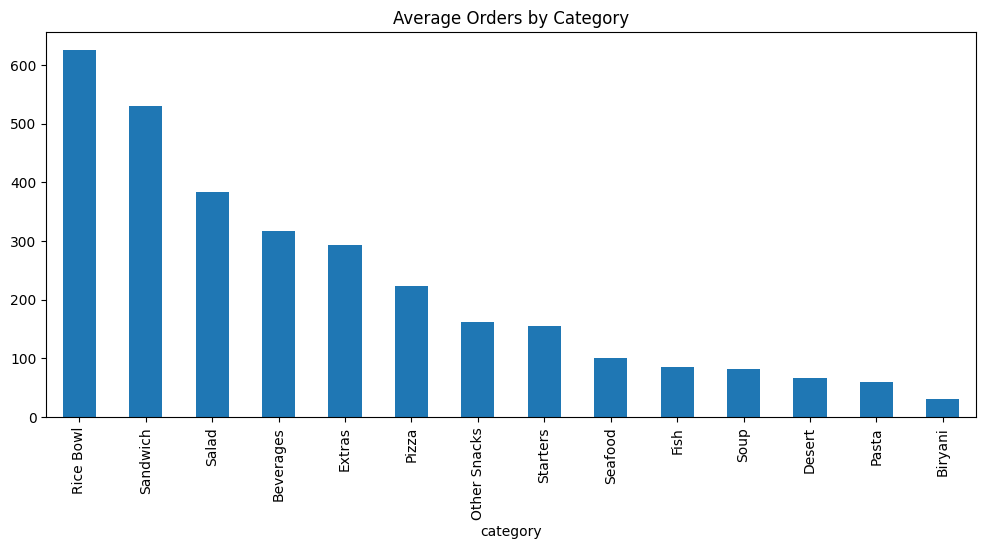

In [158]:
category_orders = (
    df.groupby('category')['num_orders']
      .mean()
      .sort_values(ascending=False)
)

category_orders.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Average Orders by Category")
plt.show()

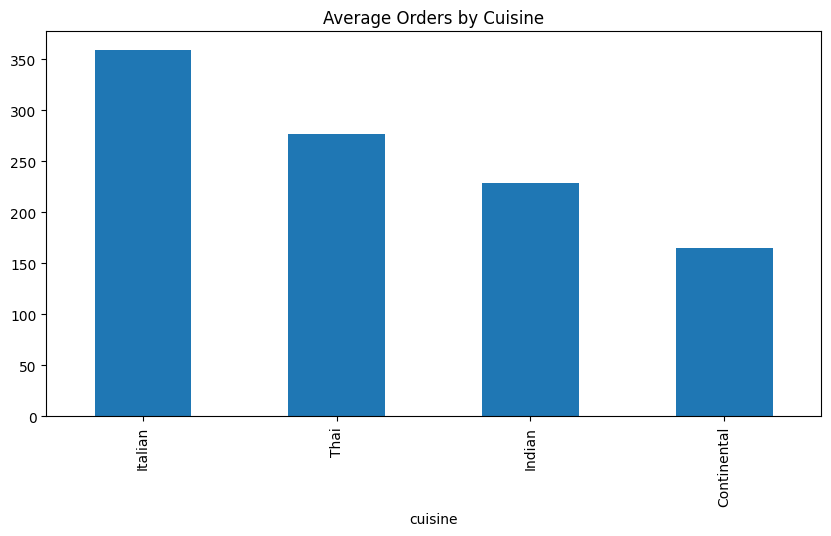

In [159]:
cuisine_orders = (
    df.groupby('cuisine')['num_orders']
      .mean()
      .sort_values(ascending=False)
)

cuisine_orders.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Average Orders by Cuisine")
plt.show()

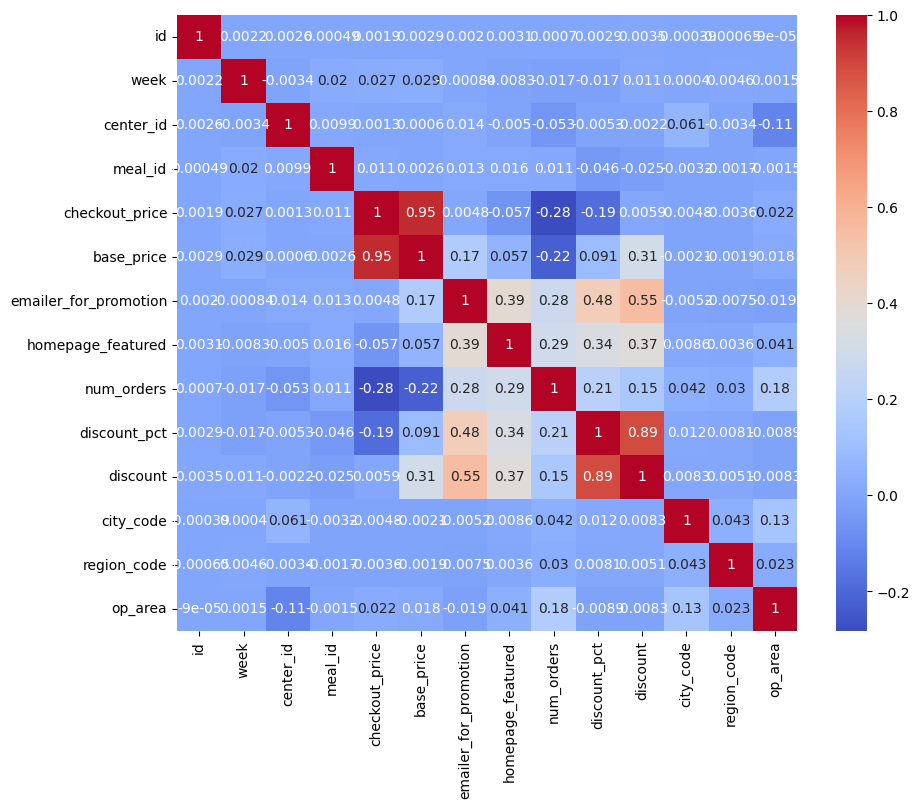

In [160]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.show()

In [161]:
df.groupby('homepage_featured')['num_orders'].agg(['mean','median','count'])

,mean,median,count
homepage_featured,,,
0,221.050040,123.0,406693
1,594.884786,350.0,49855


In [162]:
df.groupby('emailer_for_promotion')['num_orders'].agg(['mean','median','count'])

,mean,median,count
emailer_for_promotion,,,
0,229.262883,123.0,419498
1,631.097544,338.0,37050


In [163]:
df.groupby('category')['num_orders'].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
Beverages,127890.0,316.526116,375.280914,13.0,81.0,189.0,404.0,9303.0
Biryani,20614.0,30.651402,22.092493,13.0,14.0,26.0,41.0,242.0
Desert,29294.0,66.250905,60.239531,13.0,27.0,53.0,82.0,1054.0
Extras,13562.0,293.834169,232.045222,13.0,123.0,217.0,393.0,1620.0
Fish,10187.0,85.595268,80.303895,13.0,28.0,67.0,109.0,879.0
Other Snacks,29379.0,162.234691,168.654453,13.0,54.0,109.0,215.0,3861.0
Pasta,27694.0,59.137142,54.081742,13.0,26.0,42.0,80.0,824.0
Pizza,33138.0,222.817309,227.976970,13.0,82.0,149.0,271.0,2620.0
Rice Bowl,33408.0,624.822288,745.306184,13.0,258.0,433.0,717.0,24299.0


In [164]:
df_model = pd.get_dummies(
    df,
    columns=['category', 'cuisine', 'center_type'],
    drop_first=True
)

df_model.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,discount_pct,...,category_Salad,category_Sandwich,category_Seafood,category_Soup,category_Starters,cuisine_Indian,cuisine_Italian,cuisine_Thai,center_type_TYPE_B,center_type_TYPE_C
0,1379560,1,55,1885,136.83,152.29,0,0,177,10.151684,...,False,False,False,False,False,False,False,True,False,True
1,1466964,1,55,1993,136.83,135.83,0,0,270,-0.736214,...,False,False,False,False,False,False,False,True,False,True
2,1346989,1,55,2539,134.86,135.86,0,0,189,0.736052,...,False,False,False,False,False,False,False,True,False,True
3,1338232,1,55,2139,339.50,437.53,0,0,54,22.405321,...,False,False,False,False,False,True,False,False,False,True
4,1448490,1,55,2631,243.50,242.50,0,0,40,-0.412371,...,False,False,False,False,False,True,False,False,False,True


In [165]:
X = df_model.drop('num_orders', axis=1)
X = X.drop(columns=['id'])

y = df_model['num_orders']

In [166]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [167]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [168]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

print("MAE :", mean_absolute_error(y_test, pred_lr))

print("RMSE :", np.sqrt(
    mean_squared_error(y_test, pred_lr)
))

print("R2 :", r2_score(y_test, pred_lr))

MAE : 162.0829699514403
RMSE : 296.48950770802594
R2 : 0.42369352298001683


In [169]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [170]:
print("MAE :", mean_absolute_error(y_test, pred_rf))

print("RMSE :", np.sqrt(
    mean_squared_error(y_test, pred_rf)
))

print("R2 :", r2_score(y_test, pred_rf))

MAE : 68.83067243456358
RMSE : 145.38354204139486
R2 : 0.8614312390190224


In [171]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

importance.head(20)

,Feature,Importance
3,checkout_price,0.172703
11,op_area,0.119907
19,category_Rice Bowl,0.088166
6,homepage_featured,0.086919
4,base_price,0.061378
0,week,0.060791
2,meal_id,0.054749
1,center_id,0.052071
7,discount_pct,0.050789
21,category_Sandwich,0.050028


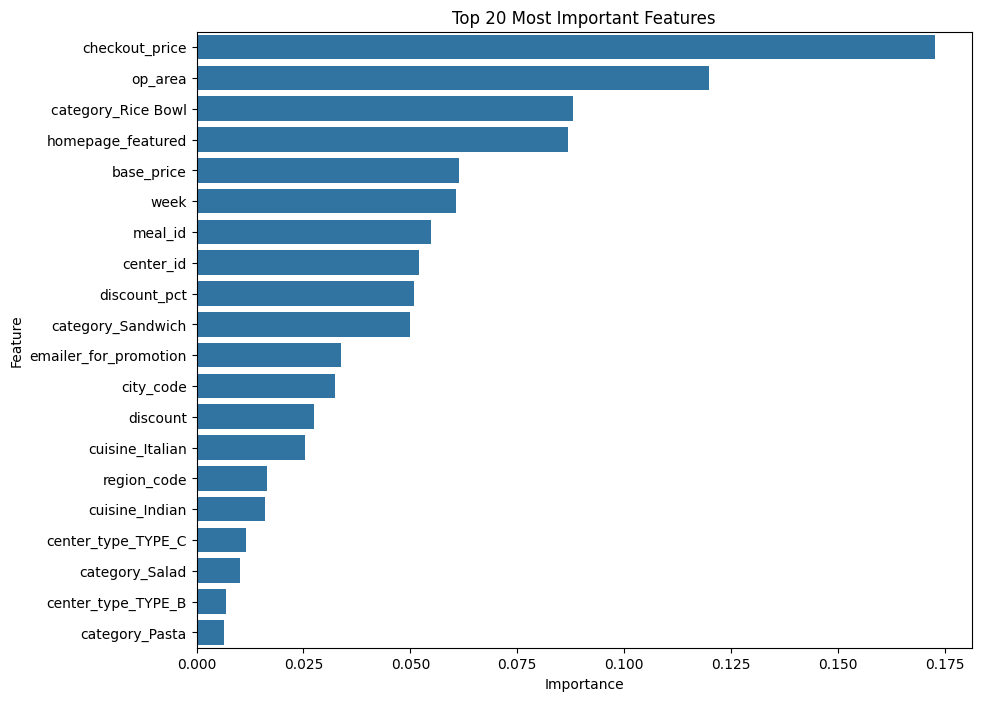

In [172]:
top20 = importance.head(20)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top20,
    x='Importance',
    y='Feature'
)

plt.title("Top 20 Most Important Features")
plt.show()

In [173]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

gbr.fit(X_train, y_train)

pred_gbr = gbr.predict(X_test)

In [174]:
print("MAE :", mean_absolute_error(y_test, pred_gbr))

print("RMSE :", np.sqrt(
    mean_squared_error(y_test, pred_gbr)
))

print("R2 :", r2_score(y_test, pred_gbr))

MAE : 117.16529015768215
RMSE : 223.80198563213295
R2 : 0.6716305743102668


In [177]:
from xgboost import XGBRegressor

XGBRegressor(
        n_estimators=[300, 500, 700],
        max_depth=[6, 8, 10],
        learning_rate=[0.03, 0.05, 0.1],
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

print("R2 :", r2_score(y_test, pred_xgb))

TypeError: 'list' object cannot be interpreted as an integer